SOURCE:https://www.quantlibguide.com/Market%20quotes.html

We have already seen in other examples how instances of SimpleQuote can be updated and how they notify their observers. In this notebook, I’ll show a possible pitfall to avoid when multiple quotes need to be updated.

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import QuantLib as ql

In [3]:
today = ql.Date(17, ql.October, 2016)
ql.Settings.instance().evaluationDate = today

<h2>Setting the stage</h2>

For illustration purposes, I’ll create a bond curve using the same data and algorithm shown in one of the QuantLib C++ examples; namely, I’ll give to the curve the functional form defined by the Nelson-Siegel model and I’ll fit it to a number of bonds. Here are the maturities in years and the coupons of the bonds I’ll use:

In [4]:
data = [
    (2, 0.02),
    (4, 0.0225),
    (6, 0.025),
    (8, 0.0275),
    (10, 0.03),
    (12, 0.0325),
    (14, 0.035),
    (16, 0.0375),
    (18, 0.04),
    (20, 0.0425),
    (22, 0.045),
    (24, 0.0475),
    (26, 0.05),
    (28, 0.0525),
    (30, 0.055),
]

In [10]:
calendar = ql.TARGET()
settlement = calendar.advance(today, 3, ql.Days)
quotes = []
helpers = []

for length, coupon in data:
    maturity = calendar.advance(settlement, length, ql.Years)
    schedule = ql.Schedule(
        settlement,
        maturity,
        ql.Period(ql.Annual),
        calendar,
        ql.ModifiedFollowing,
        ql.ModifiedFollowing,
        ql.DateGeneration.Backward,
        False
    )
    quote = ql.SimpleQuote(100.0)
    quotes.append(quote)
    helpers.append(
        ql.FixedRateBondHelper(
            ql.QuoteHandle(quote),
            3,
            100.0,
            schedule,
            [coupon],
            ql.SimpleDayCounter(),
            ql.ModifiedFollowing
        )
    )

curve = ql.FittedBondDiscountCurve(
    0, calendar, helpers, ql.SimpleDayCounter(), ql.NelsonSiegelFitting()
)

Just for kicks, here is a visualization of the curve as discount factors versus time in years:

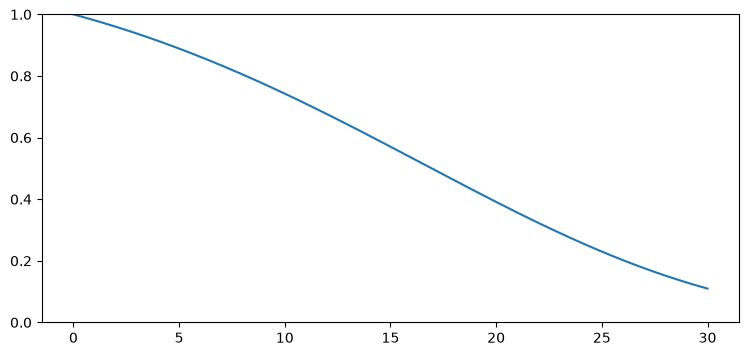

In [11]:
sample_times = np.linspace(0.0, 30.0, 301)
sample_discounts =[curve.discount(t) for t in sample_times]

ax = plt.figure(figsize=(9,4)).add_subplot(1,1,1)
ax.set_ylim(0.0, 1.0)
ax.plot(sample_times, sample_discounts)

And here is a bond priced by discounting its coupons on the curve:

In [12]:
schedule = ql.Schedule(
    today,
    calendar.advance(today, 15, ql.Years),
    ql.Period(ql.Semiannual),
    calendar,
    ql.ModifiedFollowing,
    ql.ModifiedFollowing,
    ql.DateGeneration.Backward,
    False
)

bond = ql.FixedRateBond(3, 100.0, schedule, [0.04], ql.Actual360())
bond.setPricingEngine(
    ql.DiscountingBondEngine(ql.YieldTermStructureHandle(curve))
)
print(bond.cleanPrice())

105.77449622178025


In [13]:
prices = []

def print_price():
    p= bond.cleanPrice()
    prices.append(p)
    print(p)

o = ql.Observer(print_price)
o.registerWith(bond)

In [14]:
quotes[2].setValue(101.0)

105.77449622178025
105.86560413454633


Whoa, what was that? The function was called twice, which surprised me too when I wrote this notebook. It turns out that, due to a glitch of multiple inheritance, the curve sends two notifications to the instrument. After the first, the instrument recalculates but the curve doesn’t (which explains why the price doesn’t change); after the second, the curve updates and the price changes. This should be fixed in a future release.

Let’s set the quote back to its original value.

In [15]:
quotes[2].setValue(100.0)

105.86560413454633
105.77449632602422


Now, let’s say the market moves up and, accordingly, all the bonds prices increase to 101. Therefore, we need to update all the quotes.

In [16]:
prices = []
for q in quotes:
    q.setValue(101.0)

105.77449632602422
105.28388421801475
105.28388421801475
105.2186292238055
105.2186292238055
105.31959063332916
105.31959063332916
105.4878663261018
105.4878663261018
105.68032057288742
105.68032057288742
105.87580396665263
105.87580396665263
106.06201692071569
106.06201692071569
106.23044659597666
106.23044659597666
106.37409219514531
106.37409219514531
106.48708840535757
106.48708840535757
106.56505216839506
106.56505216839506
106.6057074004982
106.6057074004982
106.60980178159524
106.60980178159524
106.58011175261714
106.58011175261714
106.52070688437946


As you see, each of the updates sent a notification and thus triggered a recalculation. We can use the list of prices we collected (slicing it to skip duplicate values) to visualize how the price changed.

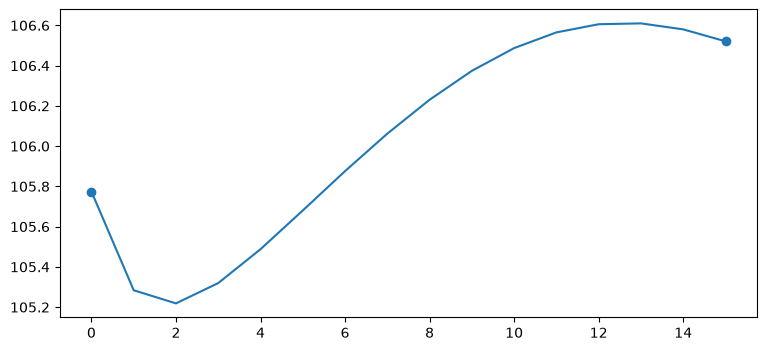

In [20]:
initial_price = prices[0]
updated_prices=prices[1::2]
ax=plt.figure(figsize=(9,4)).add_subplot(1,1,1)
(p,) = ax.plot([initial_price] + updated_prices,"-")
ax.plot(0, initial_price, "o", color=p.get_color())
ax.plot(len(updated_prices),updated_prices[-1],"o", color=p.get_color())

The first value is the original bond price, and the last value is the final price after all the quotes were updated; but all the prices in between were calculated based on an incomplete set of changes in which some quotes were updated and some others weren’t. They are all incorrect, and (since they went both above and below the range of the real prices) also outright dangerous: in case your application defined any triggers on price levels, they might have fired incorrectly. Clearly, this is not the kind of behavior we want our code to have.

<h2>Alternatives</h2>

There are workarounds we can apply. For instance, it’s possible to freeze the bond temporarily, preventing it from forwarding notifications.

In [22]:
bond.freeze()

Now, notifications won’t be forwarded by the bond and thus won’t reach our observer. In fact, the following loop won’t print anything.

In [23]:
for q in quotes:
    q.setValue(101.5)

In [24]:
bond.unfreeze()

106.85839332472605


<h2>Pull, don't push</h2>

It’s preferable for updates to not trigger recalculation, just like the instruments in the library do. This way, you can control when the calculation occur.

To do so, let’s remove the observer we have in place.

In [25]:
del o

Our application code knows when a set of changes is published together (reflecting a change of the whole market subset we’re tracking). Therefore, it should apply all the changes, and only afterwards it should send some kind of application-level notification that your bonds should be asked for new prices. The ones that depend on the changed quotes will have received their notifications, and will recalculate when asked for a price; other bonds that don’t depend on the changed quotes won’t have received any notifications and won’t recalculate.

In [26]:
for q in quotes:
    q.setValue(101.0)

bond.cleanPrice()

106.52070693303892